In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
# High-Level LSTM API
#
# LSTM
# ├─ Input Gate: 새 정보 기록
# ├─ Forget Gate: 기존 정보 유지 또는 삭제
# ├─ Output Gate: 저장된 정보 공개
# ├─ Memory Cell C: 내부 장기 기억
# └─ Hidden State H: 외부 전달 정보

class LSTM(d2l.RNN):
    num_inputs: int
    num_hiddens: int

    def __init__(
        self,
        num_inputs: int,  # Input feature 
        num_hiddens: int, # hidden unit
    ) -> None:
        
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        
        # Parameter Initialzation
        self.rnn = nn.LSTM(
            input_size=num_inputs,   # D
            hidden_size=num_hiddens, # H
        )
        
    
    def forward(
        self,
        inputs: torch.Tensor,
        state: tuple[
            torch.Tensor,
            torch.Tensor,
        ] | None = None,
    ) -> tuple[
        torch.Tensor,
        tuple[torch.Tensor, torch.Tensor],
    ]:
        # inputs:  [T, B, D]
        # outputs: [T, B, H]
        #
        # final H: [num_layers, B, H]
        # final C: [num_layers, B, H]
        return self.rnn(
            inputs,
            state,
        )

In [ ]:
# Concise LSTM Shape Check

batch_size = 2
num_steps = 3
num_inputs = 4
num_hiddens = 8

lstm = LSTM(
    num_inputs=num_inputs,
    num_hiddens=num_hiddens,
)

# [T, B, D]
inputs = torch.randn(
    num_steps,
    batch_size,
    num_inputs,
)

# outputs    : [T, B, H]
# final_state: (H, C) = ([B, H], [B, H])
outputs, final_state = lstm(
    inputs
)

final_H, final_C = final_state

actual_num_parameters = sum(
    parameter.numel()
    for parameter in lstm.parameters()
)

expected_num_parameters = (
    4 * num_inputs * num_hiddens
    + 4 * num_hiddens * num_hiddens
    + 8 * num_hiddens
)

print(
    "Input shape:",
    tuple(inputs.shape),
)
print(
    "Output sequence:",
    tuple(outputs.shape),
)
print(
    "Final H:",
    tuple(final_H.shape),
)
print(
    "Final C:",
    tuple(final_C.shape),
)
print(
    "Parameter count:",
    actual_num_parameters,
)

Input shape: (3, 2, 4)
Output sequence: (3, 2, 8)
Final H: (1, 2, 8)
Final C: (1, 2, 8)
Parameter count: 448


Training device: cuda:0
Generated text: it has i wime trave the th


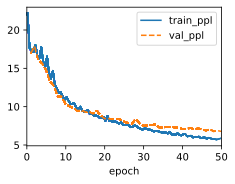

In [4]:
# Concise LSTM Training and Prediction

data = d2l.TimeMachine(
    batch_size=1024,
    num_steps=32,
)

vocab_size = len(
    data.vocab
)

lstm = LSTM(
    num_inputs=vocab_size,
    num_hiddens=32,
)

model = d2l.RNNLM(
    rnn=lstm,
    vocab_size=vocab_size,
    lr=4,
)

trainer = d2l.Trainer(
    max_epochs=50,
    gradient_clip_val=1,
    num_gpus=1,
)

trainer.fit(
    model,
    data,
)

generated_text = model.predict(
    prefix="it has",
    num_preds=20,
    vocab=data.vocab,
    device=d2l.try_gpu(),
)

model_device = next(
    model.parameters()
).device

print(
    "Training device:",
    model_device,
)
print(
    "Generated text:",
    generated_text,
)